# RNNs, LSTMs, GRUs & Word Embeddings

## 1. Recurrent Neural Networks (RNN)

RNNs process sequences by maintaining a hidden state:
$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$
$$\hat{y}_t = W_{hy} h_t + b_y$$

The **same weights** $W_{hh}$, $W_{xh}$ are reused at every timestep (parameter sharing).

### Backpropagation Through Time (BPTT)
Gradient flows back through all timesteps:
$$\frac{\partial \mathcal{L}}{\partial W} = \sum_{t=1}^T \frac{\partial \mathcal{L}_t}{\partial W}$$

$$\frac{\partial h_t}{\partial h_k} = \prod_{i=k+1}^{t} \frac{\partial h_i}{\partial h_{i-1}} = \prod_{i=k+1}^{t} W_{hh}^T \text{diag}(\tanh'(\cdot))$$

**Vanishing gradient**: if $|W_{hh}| < 1$, gradients shrink exponentially → RNN forgets long-range dependencies.
**Exploding gradient**: if $|W_{hh}| > 1$, gradients explode → solved with gradient clipping.

## 2. Long Short-Term Memory (LSTM)

Hochreiter & Schmidhuber (1997). Introduces a **cell state** $C_t$ as a "memory highway" with gating.

### Gates:

**Forget gate** (what to erase from cell state):
$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$

**Input gate** (what new info to store):
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$

**Candidate cell state**:
$$\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C)$$

**Cell state update**:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

**Output gate**:
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$

**Hidden state**:
$$h_t = o_t \odot \tanh(C_t)$$

The cell state $C_t$ allows gradients to flow unchanged → solves vanishing gradient.

## 3. Gated Recurrent Unit (GRU)

Cho et al. (2014). Simpler than LSTM with two gates:

**Update gate** (combines forget + input):
$$z_t = \sigma(W_z [h_{t-1}, x_t] + b_z)$$

**Reset gate**:
$$r_t = \sigma(W_r [h_{t-1}, x_t] + b_r)$$

**Candidate hidden state**:
$$\tilde{h}_t = \tanh(W [r_t \odot h_{t-1}, x_t] + b)$$

**New hidden state**:
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

GRU has fewer parameters than LSTM and often performs comparably.

## 4. Bidirectional RNN

Processes sequence in **both directions**:
$$\overrightarrow{h}_t = f(\overrightarrow{W}_{hh}\overrightarrow{h}_{t-1} + W_{xh}x_t)$$
$$\overleftarrow{h}_t = f(\overleftarrow{W}_{hh}\overleftarrow{h}_{t+1} + W_{xh}x_t)$$
$$y_t = g(W_y[\overrightarrow{h}_t; \overleftarrow{h}_t])$$

Used when full sequence context is available (e.g., BERT).

## 5. Seq2Seq with Attention

**Encoder** compresses input sequence → context vector.
**Decoder** generates output using context vector.

**Problem**: Fixed-size bottleneck loses information for long sequences.

**Bahdanau Attention** (2015):
$$e_{ts} = a(s_{t-1}, h_s) = v_a^T \tanh(W_a s_{t-1} + U_a h_s)$$
$$\alpha_{ts} = \frac{\exp(e_{ts})}{\sum_{s'=1}^T \exp(e_{ts'})}$$
$$c_t = \sum_{s=1}^T \alpha_{ts} h_s$$

Decoder uses context vector $c_t$ computed as weighted sum of **all** encoder states.

## 6. Word Embeddings

### Word2Vec (Mikolov et al., 2013)

**CBOW**: predict center word from context:
$$J = -\log p(w_c | w_{c-m}, ..., w_{c+m})$$

**Skip-gram**: predict context words from center:
$$J = -\log p(w_{c-m}, ..., w_{c+m} | w_c) = -\sum_{j \neq 0, -m \leq j \leq m} \log p(w_{c+j}|w_c)$$

$$p(o|c) = \frac{\exp(u_o^T v_c)}{\sum_{w=1}^V \exp(u_w^T v_c)}$$

**Negative sampling** approximates full softmax:
$$J = \log \sigma(u_o^T v_c) + \sum_{k=1}^K \mathbb{E}_{w_k \sim P_n(w)}[\log \sigma(-u_{w_k}^T v_c)]$$

### GloVe (Pennington et al., 2014)
Factorizes the log co-occurrence matrix:
$$J = \sum_{i,j=1}^V f(X_{ij})(w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij})^2$$

### FastText (Bojanowski et al., 2017)
Represents words as bag of character n-grams. Handles out-of-vocabulary words.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LSTM from scratch in PyTorch (manual gate implementation)
# ============================================================

class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        # Combined weight matrix for all 4 gates [f, i, C_tilde, o]
        self.W = nn.Linear(input_size + hidden_size, 4 * hidden_size)

    def forward(self, x, state):
        h_prev, c_prev = state
        combined = torch.cat([h_prev, x], dim=1)
        gates = self.W(combined)
        # Split into 4 gates
        f, i, g, o = gates.chunk(4, dim=1)
        f = torch.sigmoid(f)       # forget gate
        i = torch.sigmoid(i)       # input gate
        g = torch.tanh(g)          # candidate cell
        o = torch.sigmoid(o)       # output gate
        c = f * c_prev + i * g     # new cell state
        h = o * torch.tanh(c)      # new hidden state
        return h, (h, c)


class LSTM_Scratch(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.cells = nn.ModuleList(
            [LSTMCell(input_size if l==0 else hidden_size, hidden_size)
             for l in range(num_layers)]
        )

    def forward(self, x, h0=None, c0=None):
        batch, seq_len, _ = x.shape
        if h0 is None:
            h0 = torch.zeros(len(self.cells), batch, self.hidden_size)
            c0 = torch.zeros(len(self.cells), batch, self.hidden_size)

        states = [(h0[l], c0[l]) for l in range(len(self.cells))]
        outputs = []
        for t in range(seq_len):
            inp = x[:, t, :]
            for l, cell in enumerate(self.cells):
                inp, states[l] = cell(inp, states[l])
            outputs.append(inp)
        return torch.stack(outputs, dim=1), states


# Test
lstm = LSTM_Scratch(input_size=10, hidden_size=32, num_layers=2)
x = torch.randn(8, 20, 10)  # (batch, seq, input)
out, _ = lstm(x)
print(f'LSTM from scratch: input {x.shape} → output {out.shape}')

# Verify against PyTorch built-in
lstm_torch = nn.LSTM(input_size=10, hidden_size=32, num_layers=2, batch_first=True)
out_torch, _ = lstm_torch(x)
print(f'PyTorch LSTM:      input {x.shape} → output {out_torch.shape}')

# Compare parameter counts
print(f'\nScratch LSTM params: {sum(p.numel() for p in lstm.parameters()):,}')
print(f'PyTorch LSTM params: {sum(p.numel() for p in lstm_torch.parameters()):,}')

LSTM from scratch: input torch.Size([8, 20, 10]) → output torch.Size([8, 20, 32])
PyTorch LSTM:      input torch.Size([8, 20, 10]) → output torch.Size([8, 20, 32])

Scratch LSTM params: 13,824
PyTorch LSTM params: 14,080


LSTM output: torch.Size([32, 2])


GRU  output: torch.Size([32, 2])

LSTM params: 3,648,514
GRU  params: 3,056,642


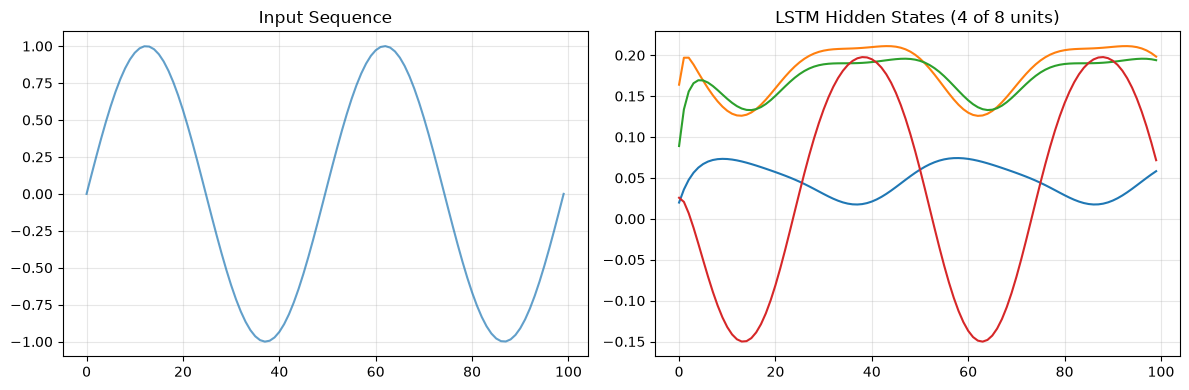

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# Sequence Classification: Sentiment Analysis with LSTM
# ============================================================

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers=num_layers,
                            batch_first=True, bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        emb = self.dropout(self.embedding(x))            # (B, L, E)
        out, (h, _) = self.lstm(emb)                     # out: (B, L, 2H)
        # Concat last hidden states from both directions
        h_final = torch.cat([h[-2], h[-1]], dim=1)       # (B, 2H)
        return self.fc(self.dropout(h_final))


# GRU variant for comparison
class SentimentGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_size, num_layers=num_layers,
                          batch_first=True, bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, h = self.gru(emb)
        h_final = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.dropout(h_final))


VOCAB_SIZE, EMBED_DIM, HIDDEN = 10000, 128, 256
lstm_model = SentimentLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN, num_layers=2, num_classes=2)
gru_model  = SentimentGRU(VOCAB_SIZE, EMBED_DIM, HIDDEN, num_layers=2, num_classes=2)

# Dummy batch
batch_tokens = torch.randint(0, VOCAB_SIZE, (32, 50))  # (batch=32, seq_len=50)
print('LSTM output:', lstm_model(batch_tokens).shape)
print('GRU  output:', gru_model(batch_tokens).shape)
print(f'\nLSTM params: {sum(p.numel() for p in lstm_model.parameters()):,}')
print(f'GRU  params: {sum(p.numel() for p in gru_model.parameters()):,}')

# Visualize gate activations on a sequence
single_lstm = nn.LSTM(input_size=1, hidden_size=8, batch_first=True)
# Create a simple sine wave sequence
t = torch.linspace(0, 4*np.pi, 100).unsqueeze(0).unsqueeze(-1)  # (1, 100, 1)
with torch.no_grad():
    output, (h_n, c_n) = single_lstm(torch.sin(t))

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(torch.sin(t.squeeze()).numpy(), label='Input (sin)', alpha=0.7)
plt.title('Input Sequence'); plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
plt.plot(output.squeeze().detach().numpy()[:, :4])
plt.title('LSTM Hidden States (4 of 8 units)'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Additional Learning Resources

### Key Papers
- **LSTM** (Hochreiter & Schmidhuber, 1997): https://www.bioinf.jku.at/publications/older/2604.pdf
- **GRU** (Cho et al., 2014): https://arxiv.org/abs/1406.1078
- **Seq2Seq** (Sutskever et al., 2014): https://arxiv.org/abs/1409.3215
- **Bahdanau Attention** (2015): https://arxiv.org/abs/1409.0473
- **Word2Vec** (Mikolov et al., 2013): https://arxiv.org/abs/1301.3781
- **GloVe** (Pennington et al., 2014): https://nlp.stanford.edu/pubs/glove.pdf
- **FastText** (Bojanowski et al., 2017): https://arxiv.org/abs/1607.04606

### Blogs
- **Understanding LSTMs** Colah's Blog: https://colah.github.io/posts/2015-08-Understanding-LSTMs/
- **The Unreasonable Effectiveness of RNNs** Karpathy: http://karpathy.github.io/2015/05/21/rnn-effectiveness/
- **Illustrated Word2Vec** Jay Alammar: https://jalammar.github.io/illustrated-word2vec/

### Courses
- **Stanford CS224n NLP with DL**: https://web.stanford.edu/class/cs224n/
- **PyTorch Sequence Models Tutorial**: https://pytorch.org/tutorials/beginner/nlp/sequence_models_tutorial.html